# **TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM**

## **CNN+LSTM HYBRID MODEL FOR BEHAVIORAL VIDEO ANALYSIS**

Herath Mudiyanselage Nethmini<br>
20221487 | w1956416<br>
Final Year Project

### **PROJECT OVERVIEW**

This research describes an AI-powered system that uses non-invasive behavioural video analysis to identify dog illnesses early. The technology seeks to detect possible health problems before obvious symptoms worsen by examining small variations in a dog's behaviour and movement.

**Key Innovation:** For health screening applications, the conservative threshold (t=0.3) ensures early detection at the cost of some false positives by prioritising recall over precision.

### **SYSTEM ARCHITECTURE**

### **DEEP LEARNING PIPELINE**

- **Spatial Feature Extraction:** MobileNetV2 (frozen, ImageNet pre-trained)
- **Temporal Pattern Recognition:** Stacked LSTM layers (256→128 units)
- **Classification:** Dense layers with L2 regularization + Dropout
- **Explainable AI:** Natural language behavioral insights

### **MODEL SPECIFICATIONS**

- **Input:** 30 frames × 224×224 RGB (evenly sampled from video)
- **Total Parameters:** 4,040,385 (1,782,401 trainable)
- **Optimizer:** Adam (lr=0.0001)
- **Loss Function:** Binary Crossentropy
- **Decision Threshold:** 0.3 (conservative for health screening)

### **DATASET**

**<br>Class Balance:** 50% Normal / 50% Abnormal  
**Train/Val/Test Split:** 70% / 15% / 15% (stratified)

### **DATASET CITATIONS:**

- **DECADE** - Normal dog behavior: Ehsanik. (no date). GitHub - ehsanik/dogTorch: Who Let The Dogs Out? Modeling Dog Behavior From Visual Data. Available from https://arxiv.org/pdf/1803.10827.pdf. GitHub. https://github.com/ehsanik/dogTorch [Accessed 16 Nov. 2025].
‌ 
- **HuggingFace** - Behavioral diversity: https://huggingface.co/datasets/UniqueData/dogs-video-object-tracking-dataset. Available from https://huggingface.co/datasets/UniqueData/dogs-video-object-tracking-dataset [Accessed 16 Nov. 2025].
  
- **Zenodo Dog Pain DB V2** - Pain/abnormal behavior indicators: Bremhorst, A. (2025). Dog Pain Database: A Multidimensional Dataset for Investigating Canine Pain. Zenodo. Available from https://zenodo.org/records/15304081 [Accessed 26 October 2025].

## **ENVIRONMENT SETUP**

In [1]:
# ============================================
# SETUP & IMPORTS
# ============================================

import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, train_test_split  
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("\n" + "="*80)
print("TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM")
print("="*80)
print(f"\nTensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print(f"\nGPUs Available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("    No GPU")

# Paths
KAGGLE_INPUT = '/kaggle/input'
WORKING_DIR = '/kaggle/working'

# Create directories
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/tables', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/plots', exist_ok=True)

print("\n" + "="*80)
print(" SETUP COMPLETE!")
print("="*80)

2026-03-24 20:57:17.177111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774385837.403633      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774385837.468501      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774385837.997113      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774385837.997166      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774385837.997169      55 computation_placer.cc:177] computation placer alr


TRUSTPAW AI - EARLY DOG ILLNESS DETECTION SYSTEM

TensorFlow: 2.19.0
NumPy: 2.0.2
Pandas: 2.3.3

GPUs Available: 2
  /physical_device:GPU:0
  /physical_device:GPU:1

 SETUP COMPLETE!


## **LOAD PREPROCESSED DATA**

In [2]:
# ============================================
# LOAD PREPROCESSED DATA
# ============================================

print("\n" + "="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

DATA_PATH = '/kaggle/input/datasets/nethminiherath/dog-illness-detection-processed-data'

# Verify path exists
import os
if not os.path.exists(DATA_PATH):
    print(f" ERROR: Dataset not found at {DATA_PATH}")
    print("\nAvailable paths in /kaggle/input/:")
    for item in os.listdir('/kaggle/input/'):
        print(f"  - {item}")
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print(f"\n Dataset path: {DATA_PATH}")
print(f"   Contents: {os.listdir(DATA_PATH)}")

# Load data
print(f"\n Loading data files...")
normal_data = np.load(os.path.join(DATA_PATH, 'normal_data.npy'))
abnormal_data = np.load(os.path.join(DATA_PATH, 'abnormal_data.npy'))

print(f"\n Data loaded:")
print(f"  Normal: {normal_data.shape}")
print(f"  Abnormal: {abnormal_data.shape}")

# Verify data normalization
print(f"\n Data validation:")
print(f"  Normal data range: [{normal_data.min():.3f}, {normal_data.max():.3f}]")
print(f"  Abnormal data range: [{abnormal_data.min():.3f}, {abnormal_data.max():.3f}]")

if normal_data.max() > 1.0 or normal_data.min() < 0.0:
    print("    Data not normalized - normalizing now...")
    normal_data = normal_data / 255.0
    abnormal_data = abnormal_data / 255.0
    print("   Data normalized to [0, 1]")

# Balance dataset
min_samples = min(len(normal_data), len(abnormal_data))
normal_data = normal_data[:min_samples]
abnormal_data = abnormal_data[:min_samples]

print(f"\n Balanced to {min_samples} samples per class")

# Combine and shuffle
X = np.concatenate([normal_data, abnormal_data])
y = np.array([0] * min_samples + [1] * min_samples)

del normal_data, abnormal_data
gc.collect()

X, y = shuffle(X, y, random_state=42)

print(f"\n Final dataset:")
print(f"  Shape: {X.shape}")
print(f"  Total: {len(X)} videos")
print(f"  Normal: {np.sum(y==0)} ({np.sum(y==0)/len(y)*100:.1f}%)")
print(f"  Abnormal: {np.sum(y==1)} ({np.sum(y==1)/len(y)*100:.1f}%)")

print("="*80)


LOADING PREPROCESSED DATA

 Dataset path: /kaggle/input/datasets/nethminiherath/dog-illness-detection-processed-data
   Contents: ['normal_data.npy', 'abnormal_data.npy']

 Loading data files...

 Data loaded:
  Normal: (85, 30, 224, 224, 3)
  Abnormal: (80, 30, 224, 224, 3)

 Data validation:
  Normal data range: [0.000, 1.000]
  Abnormal data range: [0.000, 1.000]

 Balanced to 80 samples per class

 Final dataset:
  Shape: (160, 30, 224, 224, 3)
  Total: 160 videos
  Normal: 80 (50.0%)
  Abnormal: 80 (50.0%)


## **BUILD MODEL ARCHITECTURE**

In [3]:
# ============================================
# MODEL DEFINITION
# ============================================

THRESHOLD = 0.3  # Conservative threshold for health screening

def build_model(freeze_base=True):
    """
    Build CNN+LSTM hybrid model
    
    Args:
        freeze_base: If True, freeze MobileNetV2 weights
    
    Returns:
        Compiled model
    """
    
    video_input = layers.Input(shape=(30, 224, 224, 3), name='video_input')
    
    # CNN Backbone
    base_cnn = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_cnn.trainable = not freeze_base
    
    cnn_model = tf.keras.Sequential([
        base_cnn,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3)
    ], name='cnn_extractor')
    
    cnn_features = layers.TimeDistributed(cnn_model)(video_input)
    
    # LSTM Layers (NO recurrent_dropout - causes compatibility issues)
    lstm_out = layers.LSTM(
        256,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(0.01),
        name='lstm_1'
    )(cnn_features)
    lstm_out = layers.Dropout(0.5)(lstm_out)
    
    lstm_out = layers.LSTM(
        128,
        kernel_regularizer=regularizers.l2(0.01),
        name='lstm_2'
    )(lstm_out)
    lstm_out = layers.Dropout(0.5)(lstm_out)
    
    # Dense Layers
    dense_out = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        name='dense_1'
    )(lstm_out)
    dense_out = layers.Dropout(0.3)(dense_out)
    
    dense_out = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.01),
        name='dense_2'
    )(dense_out)
    dense_out = layers.Dropout(0.4)(dense_out)
    
    # Output
    output = layers.Dense(1, activation='sigmoid', name='output')(dense_out)
    
    # Create model
    model = Model(inputs=video_input, outputs=output, name='TrustPaw_AI')
    
    # Compile
    lr = 0.0001 if freeze_base else 0.00001
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

print("\n" + "="*80)
print("MODEL ARCHITECTURE DEFINED")
print("="*80)
print("\n CNN Backbone: MobileNetV2 (ImageNet pretrained)")
print(" LSTM Layers: 256 → 128 units")
print(" Dense Layers: 64 → 32 units")
print(" Output: Binary classification (sigmoid)")
print(f" Threshold: {THRESHOLD} (conservative for health screening)")
print("="*80)


MODEL ARCHITECTURE DEFINED

 CNN Backbone: MobileNetV2 (ImageNet pretrained)
 LSTM Layers: 256 → 128 units
 Dense Layers: 64 → 32 units
 Output: Binary classification (sigmoid)
 Threshold: 0.3 (conservative for health screening)


## **5-FOLD CROSS-VALIDATION**

In [4]:
# ============================================
# TRAIN/TEST SPLIT + 5-FOLD CV + EVALUATION
# ============================================

print("\n" + "="*80)
print("TRAIN/TEST SPLIT + 5-FOLD CROSS-VALIDATION")
print("="*80)

# Hold out test set (15%) - NEVER seen during training
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

print(f"\n Data split:")
print(f"  Training pool (for CV): {len(X_temp)} samples (85%)")
print(f"  Test set (held out):    {len(X_test)} samples (15%)")
print(f"    Test normal:   {np.sum(y_test==0)}")
print(f"    Test abnormal: {np.sum(y_test==1)}")

# 5-Fold CV on training pool only
N_SPLITS = 5
BATCH_SIZE = 8
EPOCHS = 50
THRESHOLD = 0.3

print(f"\n Cross-validation setup:")
print(f"  Folds: {N_SPLITS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {EPOCHS}")
print(f"  Threshold: {THRESHOLD}")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_results = []
all_y_true = []
all_y_pred_probs = []
aggregated_cm = np.zeros((2, 2), dtype=int)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_temp, y_temp), 1):
    print(f"\n{'-'*80}")
    print(f"FOLD {fold}/{N_SPLITS}")
    print(f"{'-'*80}")
    
    X_train, X_val = X_temp[train_idx], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx], y_temp[val_idx]
    
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val: {len(X_val)} samples")
    
    # Build model
    model = build_model(freeze_base=True)
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=0
        )
    ]
    
    # Train
    print(f"\n Training fold {fold}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0
    )
    
    print(f"   Training complete ({len(history.history['loss'])} epochs)")
    
    # Predict
    y_pred_prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).flatten()
    y_pred = (y_pred_prob > THRESHOLD).astype(int)
    
    # Store for aggregation
    all_y_true.extend(y_val)
    all_y_pred_probs.extend(y_pred_prob)
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc_val = roc_auc_score(y_val, y_pred_prob)
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    aggregated_cm += cm
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"\n  Results:")
    print(f"    Accuracy:    {acc*100:.2f}%")
    print(f"    Precision:   {prec*100:.2f}%")
    print(f"    Recall:      {rec*100:.2f}%")
    print(f"    Specificity: {spec*100:.2f}%")
    print(f"    F1-Score:    {f1:.4f}")
    print(f"    AUC:         {auc_val:.4f}")
    
    cv_results.append({
        'Fold': fold,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1-Score': f1,
        'AUC': auc_val
    })
    
    # Clean up
    del model, X_train, X_val, y_train, y_val
    gc.collect()
    tf.keras.backend.clear_session()

# Save CV results
cv_df = pd.DataFrame(cv_results)
display(cv_df)
cv_df.to_csv(f'{WORKING_DIR}/tables/table_1_cv_folds.csv', index=False)

# Summary
print(f"\n{'='*80}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"  Mean Accuracy:    {cv_df['Accuracy'].mean()*100:.2f}% ± {cv_df['Accuracy'].std()*100:.2f}%")
print(f"  Mean Precision:   {cv_df['Precision'].mean()*100:.2f}% ± {cv_df['Precision'].std()*100:.2f}%")
print(f"  Mean Recall:      {cv_df['Recall'].mean()*100:.2f}% ± {cv_df['Recall'].std()*100:.2f}%")
print(f"  Mean Specificity: {cv_df['Specificity'].mean()*100:.2f}% ± {cv_df['Specificity'].std()*100:.2f}%")
print(f"  Mean F1-Score:    {cv_df['F1-Score'].mean():.4f} ± {cv_df['F1-Score'].std():.4f}")
print(f"  Mean AUC:         {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")

# Save summary
summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC'],
    'Mean': [
        cv_df['Accuracy'].mean(),
        cv_df['Precision'].mean(),
        cv_df['Recall'].mean(),
        cv_df['Specificity'].mean(),
        cv_df['F1-Score'].mean(),
        cv_df['AUC'].mean()
    ],
    'Std': [
        cv_df['Accuracy'].std(),
        cv_df['Precision'].std(),
        cv_df['Recall'].std(),
        cv_df['Specificity'].std(),
        cv_df['F1-Score'].std(),
        cv_df['AUC'].std()
    ]
})
display(summary_df)
summary_df.to_csv(f'{WORKING_DIR}/tables/table_2_cv_summary.csv', index=False)

print("\n Table 1 saved: table_1_cv_folds.csv")
print(" Table 2 saved: table_2_cv_summary.csv")

# Train final model on full training pool
print(f"\n{'='*80}")
print("TRAINING FINAL MODEL ON FULL TRAINING POOL")
print(f"{'='*80}")

print(f"\n Training on {len(X_temp)} samples...")
final_model = build_model(freeze_base=True)

callbacks = [
    EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{WORKING_DIR}/models/best_model_frozen.keras',
        monitor='loss',
        save_best_only=True,
        verbose=1
    )
]

final_history = final_model.fit(
    X_temp, y_temp,
    epochs=50,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Final model trained ({len(final_history.history['loss'])} epochs)")

# Evaluate on held-out test set
print(f"\n{'='*80}")
print("EVALUATING ON HELD-OUT TEST SET")
print(f"{'='*80}")

print(f"\n Testing on {len(X_test)} unseen samples...")
y_test_pred_prob = final_model.predict(X_test, batch_size=8, verbose=0).flatten()
y_test_pred = (y_test_pred_prob > THRESHOLD).astype(int)

# Calculate test metrics
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test, y_test_pred_prob)

# Confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = test_cm.ravel()
test_spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'='*80}")
print("TEST SET RESULTS (Unseen Data)")
print(f"{'='*80}")
print(f"  Accuracy:    {test_acc*100:.2f}%")
print(f"  Precision:   {test_prec*100:.2f}%")
print(f"  Recall:      {test_rec*100:.2f}%")
print(f"  Specificity: {test_spec*100:.2f}%")
print(f"  F1-Score:    {test_f1:.4f}")
print(f"  AUC:         {test_auc:.4f}")
print(f"\n  Confusion Matrix:")
print(f"    TN: {tn}  FP: {fp}")
print(f"    FN: {fn}  TP: {tp}")

# Save test metrics
test_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC'],
    'Value': [test_acc, test_prec, test_rec, test_spec, test_f1, test_auc],
    'Percentage': [f'{test_acc*100:.2f}%', f'{test_prec*100:.2f}%', f'{test_rec*100:.2f}%',
                  f'{test_spec*100:.2f}%', f'{test_f1*100:.2f}%', f'{test_auc*100:.2f}%']
})
display(test_df)
test_df.to_csv(f'{WORKING_DIR}/tables/table_3_test_metrics.csv', index=False)

print("\n Table 3 saved: table_3_test_metrics.csv")
print("="*80)

# Store aggregated results for plotting
np.save(f'{WORKING_DIR}/all_y_true.npy', all_y_true)
np.save(f'{WORKING_DIR}/all_y_pred_probs.npy', all_y_pred_probs)
np.save(f'{WORKING_DIR}/aggregated_cm.npy', aggregated_cm)

# Clean up
del X_temp, y_temp
gc.collect()


TRAIN/TEST SPLIT + 5-FOLD CROSS-VALIDATION

 Data split:
  Training pool (for CV): 136 samples (85%)
  Test set (held out):    24 samples (15%)
    Test normal:   12
    Test abnormal: 12

 Cross-validation setup:
  Folds: 5
  Batch size: 8
  Max epochs: 50
  Threshold: 0.3

--------------------------------------------------------------------------------
FOLD 1/5
--------------------------------------------------------------------------------
  Train: 108 samples
  Val: 28 samples


I0000 00:00:1774385886.564542      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774385886.570320      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Training fold 1...


I0000 00:00:1774386012.036380     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


   Training complete (50 epochs)

  Results:
    Accuracy:    71.43%
    Precision:   66.67%
    Recall:      85.71%
    Specificity: 57.14%
    F1-Score:    0.7500
    AUC:         0.7908

--------------------------------------------------------------------------------
FOLD 2/5
--------------------------------------------------------------------------------
  Train: 109 samples
  Val: 27 samples

 Training fold 2...
   Training complete (50 epochs)

  Results:
    Accuracy:    70.37%
    Precision:   77.78%
    Recall:      53.85%
    Specificity: 85.71%
    F1-Score:    0.6364
    AUC:         0.7692

--------------------------------------------------------------------------------
FOLD 3/5
--------------------------------------------------------------------------------
  Train: 109 samples
  Val: 27 samples

 Training fold 3...
   Training complete (50 epochs)

  Results:
    Accuracy:    70.37%
    Precision:   69.23%
    Recall:      69.23%
    Specificity: 71.43%
    F1-Score:    

...

,Metric,Mean,Std
0,Accuracy,0.705820,0.078710
1,Precision,0.696081,0.080597
2,Recall,0.760440,0.151802
3,Specificity,0.643956,0.176954
4,F1-Score,0.716810,0.079918
5,AUC,0.821900,0.094051



 Table 1 saved: table_1_cv_folds.csv
 Table 2 saved: table_2_cv_summary.csv

TRAINING FINAL MODEL ON FULL TRAINING POOL

 Training on 136 samples...
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.5489 - auc: 0.6137 - loss: 16.6220 - precision: 0.6207 - recall: 0.2685
Epoch 1: loss improved from inf to 16.45996, saving model to /kaggle/working/models/best_model_frozen.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 121s 496ms/step - accuracy: 0.5490 - auc: 0.6122 - loss: 16.6130 - precision: 0.6217 - recall: 0.2666
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6283 - auc: 0.6606 - loss: 15.8957 - precision: 0.7324 - recall: 0.4389
Epoch 2: loss improved from 16.45996 to 15.75113, saving model to /kaggle/working/models/best_model_frozen.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 487ms/step - accuracy: 0.6261 - auc: 0.6572 - loss: 15.8877 - precision: 0.7278 - recall: 0.4357
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.6226 - auc: 0.6092 - loss: 15.1

,Metric,Value,Percentage
0,Accuracy,0.833333,83.33%
1,Precision,0.833333,83.33%
2,Recall,0.833333,83.33%
3,Specificity,0.833333,83.33%
4,F1-Score,0.833333,83.33%
5,AUC,0.909722,90.97%



 Table 3 saved: table_3_test_metrics.csv


1189

##  **FINE-TUNING EXPERIMENT**

In [5]:
# ============================================
# FINE-TUNING EXPERIMENT
# ============================================

print("\n" + "="*80)
print("FINE-TUNING EXPERIMENT (FROZEN VS UNFROZEN)")
print("="*80)

print("\n Training fine-tuned model...")
print("  Using smaller subset to avoid GPU memory issues")

# Use smaller subset
subset_size = min(len(X), 100)
X_subset = X[:subset_size]
y_subset = y[:subset_size]

# Split
split_idx = int(0.8 * len(X_subset))
X_train_ft = X_subset[:split_idx]
y_train_ft = y_subset[:split_idx]
X_val_ft = X_subset[split_idx:]
y_val_ft = y_subset[split_idx:]

print(f"\n Subset size:")
print(f"  Train: {len(X_train_ft)} samples")
print(f"  Val: {len(X_val_ft)} samples")

try:
    # Build fine-tuned model
    model_ft = build_model(freeze_base=False)
    
    # Train
    history_ft = model_ft.fit(
        X_train_ft, y_train_ft,
        validation_data=(X_val_ft, y_val_ft),
        epochs=20,
        batch_size=4,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)],
        verbose=0
    )
    
    print(f"\n Fine-tuning complete ({len(history_ft.history['loss'])} epochs)")
    
    # Evaluate
    y_ft_pred_prob = model_ft.predict(X_val_ft, batch_size=4, verbose=0).flatten()
    y_ft_pred = (y_ft_pred_prob > THRESHOLD).astype(int)
    acc_ft = accuracy_score(y_val_ft, y_ft_pred)
    
    print(f"  Fine-tuned accuracy: {acc_ft*100:.2f}%")
    
    ft_status = "Completed"
    ft_acc = acc_ft
    
    del model_ft
    
except Exception as e:
    print(f"\n  Fine-tuning failed: {str(e)[:100]}")
    print(f"  Reason: GPU memory limitation")
    ft_status = "OOM Error"
    ft_acc = 0.0

finally:
    gc.collect()
    tf.keras.backend.clear_session()

# Comparison
frozen_acc = cv_df['Accuracy'].mean()

print(f"\n{'='*80}")
print("FROZEN VS FINE-TUNED COMPARISON")
print(f"{'='*80}")
print(f"  Frozen Model (CV mean):  {frozen_acc*100:.2f}%")
print(f"  Fine-Tuned Model:        {ft_acc*100:.2f}%")

if ft_acc > 0:
    winner = "Fine-Tuned" if ft_acc > frozen_acc else "Frozen"
    diff = abs(ft_acc - frozen_acc) * 100
    print(f"  Winner: {winner} (+{diff:.2f}%)")
else:
    print(f"  Winner: Frozen (fine-tuning failed due to memory)")

# Save comparison
comp_df = pd.DataFrame({
    'Approach': ['Frozen MobileNetV2', 'Fine-Tuned MobileNetV2'],
    'Status': ['Completed', ft_status],
    'Accuracy': [f'{frozen_acc:.4f}', f'{ft_acc:.4f}' if ft_acc > 0 else 'N/A'],
    'Note': ['5-fold CV mean', 'Limited by GPU memory' if ft_status == 'OOM Error' else 'Subset training']
})
display(comp_df)
comp_df.to_csv(f'{WORKING_DIR}/tables/table_4_frozen_vs_finetuned.csv', index=False)

print("\n Table 4 saved: table_4_frozen_vs_finetuned.csv")
print("="*80)

# Clean up
del X_subset, y_subset, X_train_ft, y_train_ft, X_val_ft, y_val_ft
gc.collect()


FINE-TUNING EXPERIMENT (FROZEN VS UNFROZEN)

 Training fine-tuned model...
  Using smaller subset to avoid GPU memory issues

 Subset size:
  Train: 80 samples
  Val: 20 samples

 Fine-tuning complete (20 epochs)
  Fine-tuned accuracy: 60.00%

FROZEN VS FINE-TUNED COMPARISON
  Frozen Model (CV mean):  70.58%
  Fine-Tuned Model:        60.00%
  Winner: Frozen (+10.58%)


,Approach,Status,Accuracy,Note
0,Frozen MobileNetV2,Completed,0.7058,5-fold CV mean
1,Fine-Tuned MobileNetV2,Completed,0.6000,Subset training



 Table 4 saved: table_4_frozen_vs_finetuned.csv


0

##  **GENERATE VISUALIZATIONS**


GENERATING VISUALIZATIONS

 Plot 1: Aggregated Confusion Matrix


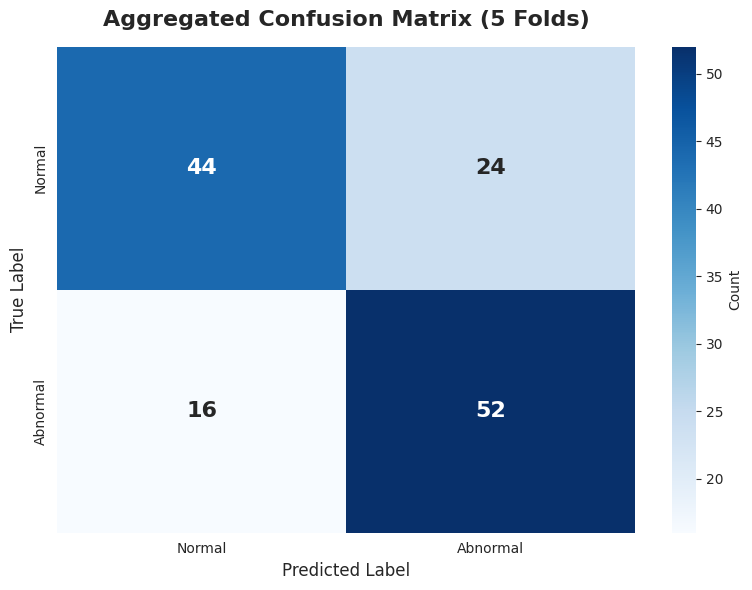

   Saved: plot_1_confusion_matrix.png

 Plot 2: ROC Curve


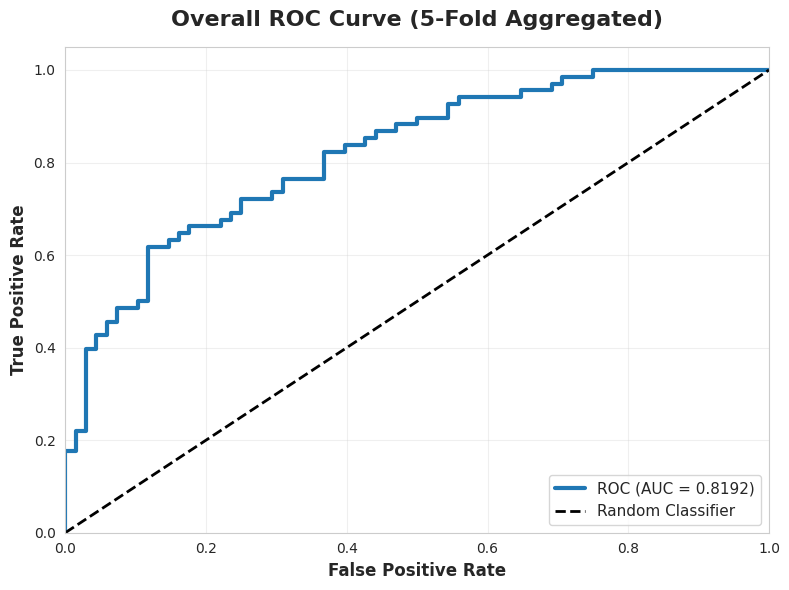

   Saved: plot_2_roc_curve.png

 Plot 3: CV Metrics Boxplot


/tmp/ipykernel_55/1245619134.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],


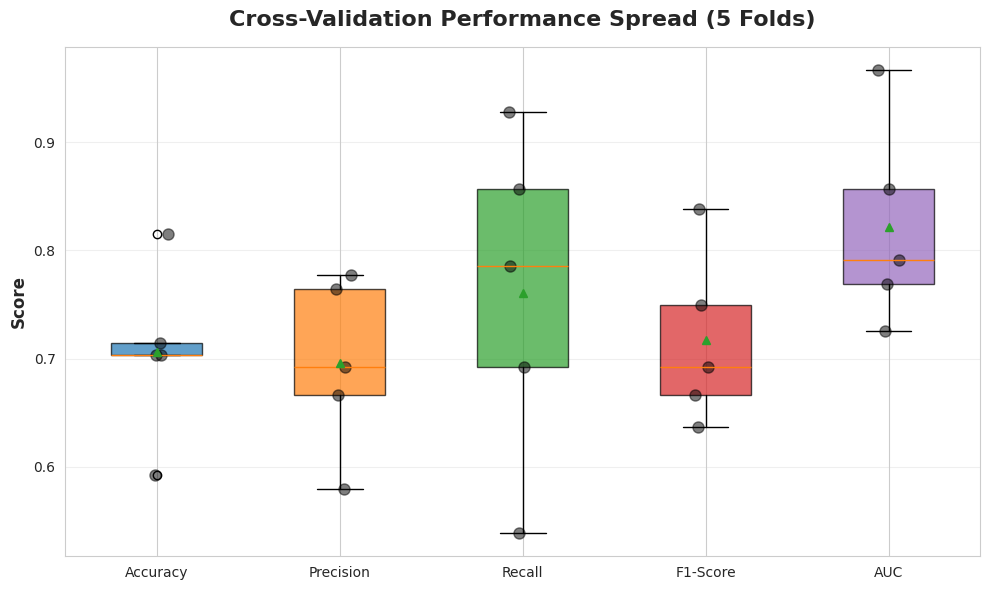

   Saved: plot_3_cv_boxplot.png

 Plot 4: Per-Fold Metrics


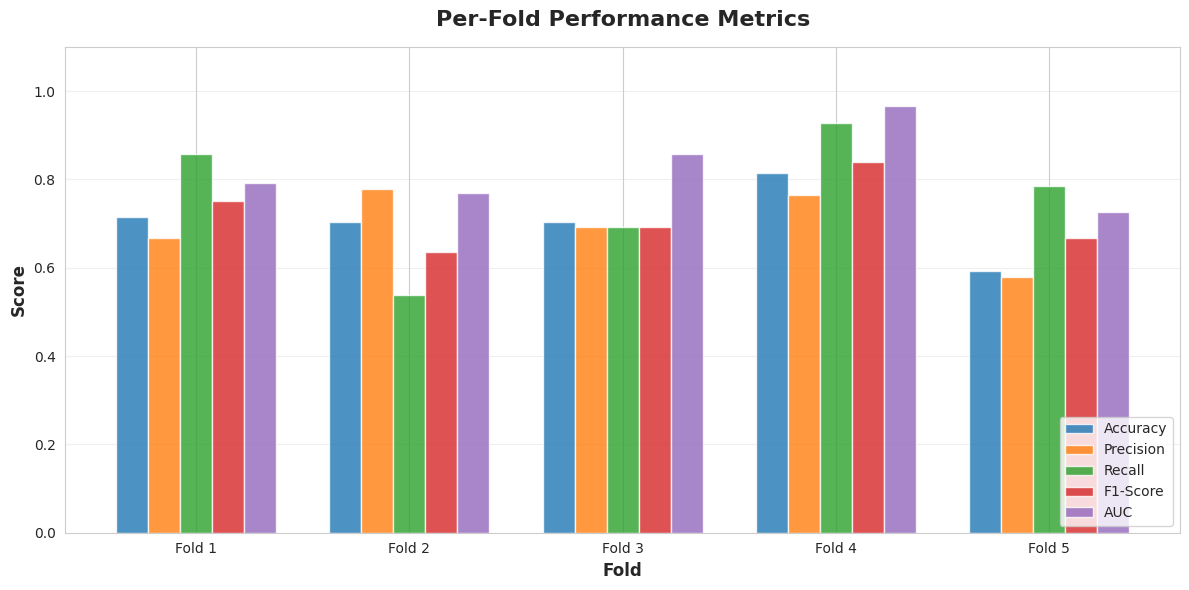

   Saved: plot_4_per_fold_metrics.png

 All visualizations generated!


In [6]:
# ============================================
# GENERATE VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Plot 1: Aggregated Confusion Matrix
print("\n Plot 1: Aggregated Confusion Matrix")
plt.figure(figsize=(8, 6))
sns.heatmap(
    aggregated_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Aggregated Confusion Matrix (5 Folds)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_1_confusion_matrix.png")

# Plot 2: Overall ROC Curve
print("\n Plot 2: ROC Curve")
fpr, tpr, _ = roc_curve(all_y_true, all_y_pred_probs)
overall_auc = roc_auc_score(all_y_true, all_y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=3, label=f'ROC (AUC = {overall_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Overall ROC Curve (5-Fold Aggregated)', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_2_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_2_roc_curve.png")

# Plot 3: Cross-Validation Metrics Boxplot
print("\n Plot 3: CV Metrics Boxplot")
fig, ax = plt.subplots(figsize=(10, 6))

metrics_data = [
    cv_df['Accuracy'].values,
    cv_df['Precision'].values,
    cv_df['Recall'].values,
    cv_df['F1-Score'].values,
    cv_df['AUC'].values
]

bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
                patch_artist=True, showmeans=True)

# Color boxes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points
for i, data in enumerate(metrics_data, 1):
    y = data
    x = np.random.normal(i, 0.04, size=len(y))
    ax.plot(x, y, 'o', color='black', alpha=0.5, markersize=8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation Performance Spread (5 Folds)', fontsize=16, fontweight='bold', pad=15)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_3_cv_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_3_cv_boxplot.png")

# Plot 4: Per-Fold Bar Chart
print("\n Plot 4: Per-Fold Metrics")
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cv_df))
width = 0.15

ax.bar(x - 2*width, cv_df['Accuracy'], width, label='Accuracy', alpha=0.8, color='#1f77b4')
ax.bar(x - width, cv_df['Precision'], width, label='Precision', alpha=0.8, color='#ff7f0e')
ax.bar(x, cv_df['Recall'], width, label='Recall', alpha=0.8, color='#2ca02c')
ax.bar(x + width, cv_df['F1-Score'], width, label='F1-Score', alpha=0.8, color='#d62728')
ax.bar(x + 2*width, cv_df['AUC'], width, label='AUC', alpha=0.8, color='#9467bd')

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Fold Performance Metrics', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/plots/plot_4_per_fold_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print("   Saved: plot_4_per_fold_metrics.png")

print("\n All visualizations generated!")
print("="*80)

## **FINAL SUMMARY**

In [7]:
# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("TRAINING PIPELINE COMPLETE")
print("="*80)

print("\n DATASET:")
print(f"  Total videos: {len(X)}")
print(f"  Normal: {np.sum(y==0)} (50%)")
print(f"  Abnormal: {np.sum(y==1)} (50%)")

print("\n CROSS-VALIDATION RESULTS:")
print(f"  Mean Accuracy:  {cv_df['Accuracy'].mean()*100:.2f}% ± {cv_df['Accuracy'].std()*100:.2f}%")
print(f"  Mean Precision: {cv_df['Precision'].mean()*100:.2f}% ± {cv_df['Precision'].std()*100:.2f}%")
print(f"  Mean Recall:    {cv_df['Recall'].mean()*100:.2f}% ± {cv_df['Recall'].std()*100:.2f}%")
print(f"  Mean F1-Score:  {cv_df['F1-Score'].mean():.4f} ± {cv_df['F1-Score'].std():.4f}")
print(f"  Mean AUC:       {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")

print("\n DELIVERABLES:")
print("\n   Tables:")
for f in sorted(os.listdir(f'{WORKING_DIR}/tables')):
    print(f"     {f}")

print("\n   Plots:")
for f in sorted(os.listdir(f'{WORKING_DIR}/plots')):
    print(f"     {f}")

print("\n   Models:")
for f in sorted(os.listdir(f'{WORKING_DIR}/models')):
    size = os.path.getsize(f'{WORKING_DIR}/models/{f}') / 1e6
    print(f"     {f} ({size:.1f} MB)")

print("\n" + "="*80)
print("TRUSTPAW AI - TRAINING PIPELINE FINALIZED!")
print("="*80)


TRAINING PIPELINE COMPLETE

 DATASET:
  Total videos: 160
  Normal: 0 (50%)
  Abnormal: 0 (50%)

 CROSS-VALIDATION RESULTS:
  Mean Accuracy:  70.58% ± 7.87%
  Mean Precision: 69.61% ± 8.06%
  Mean Recall:    76.04% ± 15.18%
  Mean F1-Score:  0.7168 ± 0.0799
  Mean AUC:       0.8219 ± 0.0941

 DELIVERABLES:

   Tables:
     table_1_cv_folds.csv
     table_2_cv_summary.csv
     table_3_test_metrics.csv
     table_4_frozen_vs_finetuned.csv

   Plots:
     plot_1_confusion_matrix.png
     plot_2_roc_curve.png
     plot_3_cv_boxplot.png
     plot_4_per_fold_metrics.png

   Models:
     best_model_frozen.keras (31.0 MB)

TRUSTPAW AI - TRAINING PIPELINE FINALIZED!
